In [1]:
import sys
import os 

import cartopy.geodesic as gd
import networkx as nx
import numpy as np
import pypsa
from shapely.geometry import Point
from scipy.sparse import spdiags

sys.path.append('./')
from power_system_split import utils, cascade_sim
from matplotlib import pyplot as plt

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import cartopy.crs as ccrs
import pickle
from scipy.sparse.csgraph import connected_components
from tqdm import tqdm
import pandas as pd
from scipy import sparse
import seaborn as sns

## You have to `pip install memory_profiler`
#%load_ext line_profiler

# Pre-outage data

In [4]:
co2l_list = [0.1] #np.arange(0.0,0.99,0.05)


inertia_results = {'lopf':{'ts':[],
                           'nodal':[]},
                   'sclopf':{'ts':[],
                             'nodal':[]}}

for network_path, prefix, name in zip(['./data/European_networks_sclopf/','./data/European_networks_lopf/'],
                                      ['sclopf-',''],
                                      ['sclopf','lopf']):
    
    # Setup paths 
    path_to_pypsa_network   = network_path

    # Setup parameters for network
    criterion = 'nodes' 
    snet_index = 0 # only AC grid of CE
    

    # Load network
    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+prefix+'elec_s_800_ec_lv1.0_Co2L0.1-3H.nc') 
    outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index# needed to remoce SCLOPF's "outage lines"
    network.mremove('Line', outage_lines)# needed to remoce SCLOPF's "outage lines"
    G = utils.build_networkx_graph(network,snet_index = snet_index)
    pos = nx.get_node_attributes(G,'pos')


    ### Calculate (total) inertia time series #####

    print('\nCalculate total inertia time series ...')
    inertia_time_series = np.zeros((len(co2l_list),2920))

    for i, co2l in enumerate(co2l_list):
        print('Co2 level %.2f' % co2l)
        level = np.round(co2l,2)
        network = pypsa.Network()
        network.import_from_netcdf(path_to_pypsa_network+prefix+f'elec_s_800_ec_lv1.0_Co2L{level}-3H.nc')  
        outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index # needed to remoce SCLOPF's "outage lines"
        network.mremove('Line', outage_lines) # needed to remoce SCLOPF's "outage lines"
        inertia_time_series[i] = utils.calc_system_inertia_over_time(network,snet_index = 0)

    inertia_results[name]['ts'] = inertia_time_series
    
    
    #### Calculate inertia generation time series per node for two Co2 levels ####

    print('\nCalculate inertia generation time series per node...')
    target_levels = [0.1]
    inertia_generation = np.zeros((len(target_levels),2,len(G.nodes())))

    for j,level in enumerate(target_levels):
        
        # Load PyPSA network for co2 level
        network = pypsa.Network()
        network.import_from_netcdf(path_to_pypsa_network+prefix+f'elec_s_800_ec_lv1.0_Co2L{np.round(level,2)}-3H.nc') 
        outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index # needed to remoce SCLOPF's "outage lines"
        network.mremove('Line', outage_lines)# needed to remoce SCLOPF's "outage lines"
        
        # Select timestamps with min and max total inertia     
        level_index = np.where(np.round(co2l_list,2) == level)[0][0]
        sorted_inertia_time_index = np.argsort(inertia_time_series[level_index])
        t_largest_inertia = network.snapshots[sorted_inertia_time_index[-1]]
        t_smallest_inertia = network.snapshots[sorted_inertia_time_index[0]]
        timestamps = [t_smallest_inertia, t_largest_inertia]
        
        # Calculate inertia generation per node
        load_shedding_indices = network.generators[network.generators.carrier.isin(['load'])].index
        for i,timestamp in enumerate(timestamps):
            current_generation = network.generators_t.p.loc[timestamp].copy()
            current_generation[load_shedding_indices] /= 1e3
            current_storage    = network.storage_units_t.p.loc[timestamp]
            for nodecount,node in enumerate(G.nodes()):
                subgraph = nx.Graph()
                subgraph.add_node(node)
                inertia_generation[j,i,nodecount] = utils.get_inertia_gen_subgraph(subgraph,
                                                                                network.generators,
                                                                                current_generation,
                                                                                network.storage_units,
                                                                                current_storage,
                                                                                use_pnom = True)
    inertia_results[name]['nodal'] = inertia_generation

     


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, lines, links, loads, storage_units



Calculate total inertia time series ...
Co2 level 0.10


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, lines, links, loads, storage_units



Calculate inertia generation time series per node...


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, lines, links, loads, storage_units
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical o


Calculate total inertia time series ...
Co2 level 0.10


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units



Calculate inertia generation time series per node...


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


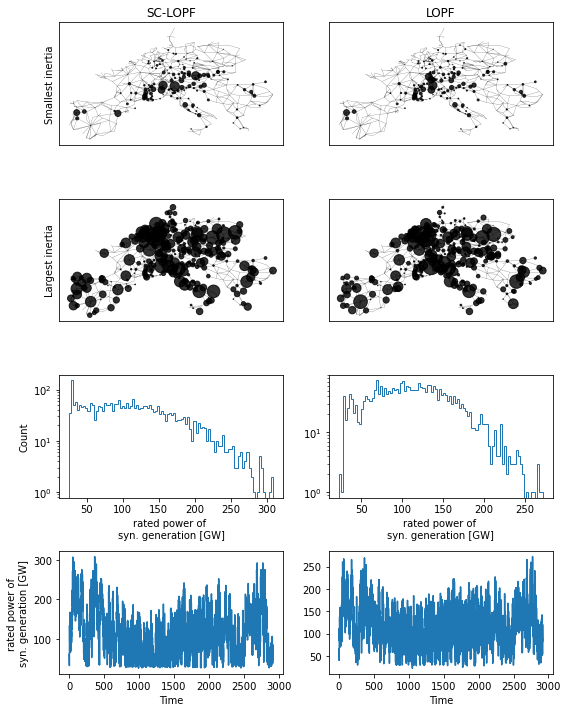

In [6]:
fig, axs = plt.subplots(4,2, figsize=(8,10))


axs[3,0].plot(inertia_results['sclopf']['ts'][0]/1000)

axs[2,0].hist(inertia_results['sclopf']['ts'][0]/1000,
            bins=100,
            histtype='step'),
axs[2,0].set_yscale('log')


axs[3,1].plot(inertia_results['lopf']['ts'][0]/1000)

axs[2,1].hist(inertia_results['lopf']['ts'][0]/1000,
            bins=100,
            histtype='step'),
axs[2,1].set_yscale('log')

for i in [0,1]:
    nx.draw_networkx_nodes(G,
                            pos,
                            ax=axs[i][0],
                            node_size=inertia_results['sclopf']['nodal'][0][i]/28,
                            alpha=0.8,
                            node_color='black')
    nx.draw_networkx_edges(G,
                            pos,
                            ax=axs[i][0],
                            alpha=0.8,
                            width=0.2)

    nx.draw_networkx_nodes(G,
                            pos,
                            ax=axs[i][1],
                            node_size=inertia_results['lopf']['nodal'][0][i]/28,
                            alpha=0.8,
                            node_color='black')
    nx.draw_networkx_edges(G,
                            pos,
                            ax=axs[i][1],
                            alpha=0.8,
                            width=0.2)

axs[0,0].set_ylabel('Smallest inertia')
axs[1,0].set_ylabel('Largest inertia')
axs[2,0].set_ylabel('Count')
axs[3,0].set_ylabel('rated power of \nsyn. generation [GW]')

axs[2,0].set_xlabel('rated power of \nsyn. generation [GW]')
axs[2,1].set_xlabel('rated power of \nsyn. generation [GW]')

axs[3,0].set_xlabel('Time')
axs[3,1].set_xlabel('Time')


axs[0,0].set_title('SC-LOPF')
axs[0,1].set_title('LOPF')

plt.tight_layout()
#plt.savefig('./fig4_lopf_sclopf_comparison.pdf')


In [7]:
dipole_results = {'lopf':{'dipole_vector':[],
                           'mean_pos':[],
                           'norm':[]},
                   'sclopf':{'dipole_vector':[],
                           'mean_pos':[],
                           'norm':[]}}

for network_path, prefix, name in zip(['./data/European_networks_sclopf/','./data/European_networks_lopf/'],
                                      ['sclopf-',''],
                                      ['sclopf','lopf']):

    # Setup paths 
    path_to_pypsa_network   = network_path
    
    #### Calculate dipole vectors ####

    print('\nCalculate dipole vectors...')
    dipole_vector = np.zeros((len(co2l_list),2,len(network.snapshots)))

    mean_consumption_vector = np.zeros((len(co2l_list),len(G.nodes())))
    graph_net_mismatch = np.zeros((len(co2l_list),len(network.snapshots)))

    for i,co2l in enumerate(co2l_list):
        
        print('Co2 level %.2f' % co2l)
        
        network = pypsa.Network()
        level = np.round(co2l,2)
        network.import_from_netcdf(path_to_pypsa_network+prefix+f'elec_s_800_ec_lv1.0_Co2L{level}-3H.nc')  
        outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index # needed to remoce SCLOPF's "outage lines"
        network.mremove('Line', outage_lines)# needed to remoce SCLOPF's "outage lines"
        
        ### NOTE: Here, the mean position is subtracted from the coordinates
        position_vector = np.array([pos[n] for n in G.nodes()])
        position_vector[:,1] -= np.mean(position_vector[:,1])
        position_vector[:,0] -= np.mean(position_vector[:,0])    
        
        nodal_balance = (network.generators_t.p.T.groupby(network.generators["bus"]).sum()-\
                        network.loads_t.p.T.groupby(network.loads["bus"]).sum()+\
                        network.storage_units_t.p.T.groupby(network.storage_units["bus"]).sum()).copy()
        
        ## add hvdc link subtraction/addition
        nodal_balance = nodal_balance.add(-network.links_t.p0.T.groupby(network.links["bus0"]).sum(), fill_value=0)
        nodal_balance = nodal_balance.add(-network.links_t.p1.T.groupby(network.links["bus1"]).sum(), fill_value=0)
        
        nodal_balance = -nodal_balance
        
        for nodecount,node in enumerate(G.nodes()):
            mean_consumption_vector[i,nodecount] = nodal_balance.mean(axis = 1).loc[node]
            graph_net_mismatch[i] += nodal_balance.loc[node]
            dipole_vector[i] += np.outer(position_vector[nodecount],nodal_balance.loc[node].to_numpy())
            

    #### Calculate spatial power inhomogeneity ####


    print('\nCalculate spatial power inhomogeneity...')
    vec_norm = np.zeros((len(co2l_list),len(network.snapshots)))
    positions = np.array([pos[n] for n in G.nodes()])
    mean_pos = np.array([np.mean(positions[:,0]),np.mean(positions[:,1])])
    scale_factor = 1e6

    k = gd.Geodesic() 

    for i,co2l in enumerate(co2l_list):
        print('Co2 level %.2f' % co2l)

        for j in range(len(network.snapshots)):
            shapely_pos = Point(dipole_vector[i,:,j]/scale_factor+mean_pos)
            distance = k.inverse(shapely_pos, Point(mean_pos))[0,0]/1000
            vec_norm[i,j] = distance


    dipole_results[name]['mean_pos'] = mean_pos
    dipole_results[name]['vec_norm'] = vec_norm
    dipole_results[name]['dipole_vector'] = dipole_vector


Calculate dipole vectors...
Co2 level 0.10


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, lines, links, loads, storage_units



Calculate spatial power inhomogeneity...
Co2 level 0.10

Calculate dipole vectors...
Co2 level 0.10


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units



Calculate spatial power inhomogeneity...
Co2 level 0.10


/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


Text(0, 0.5, 'Count')

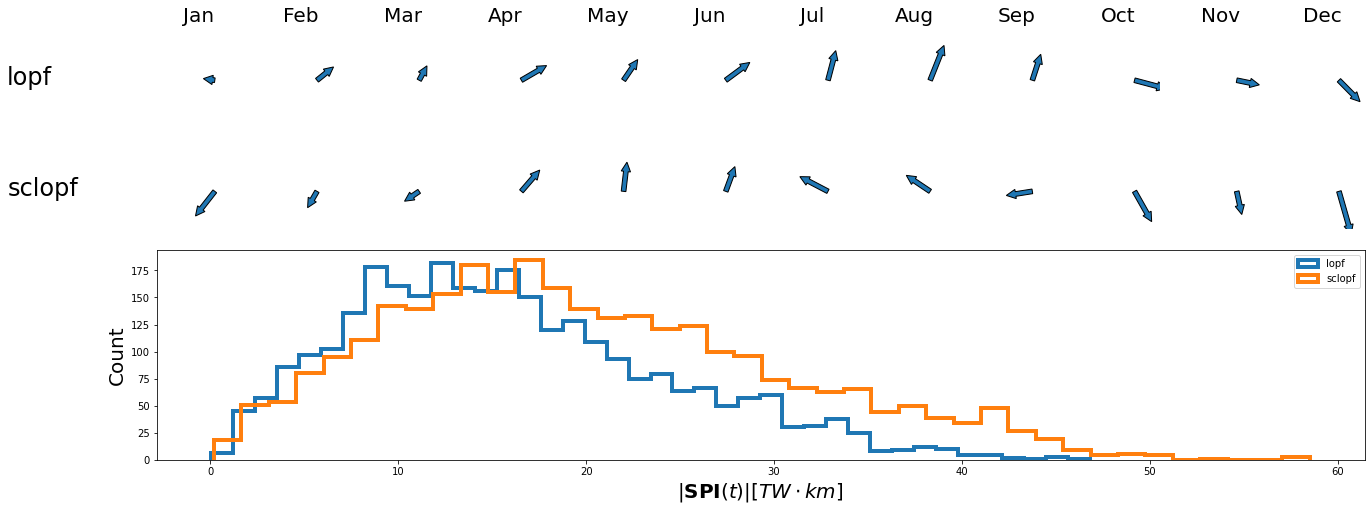

In [8]:
f = plt.figure(figsize=(19, 7), constrained_layout=True)

gs = GridSpec(3,12, figure=f, hspace=0, height_ratios=[1,1,2]) # outer grid
axs1 = [f.add_subplot(gs[0,i], projection=ccrs.PlateCarree()) for i in range(12)]
axs2 = [f.add_subplot(gs[1,i], projection=ccrs.PlateCarree()) for i in range(12)]
axs3 = f.add_subplot(gs[2, :])

network_old = pypsa.Network()
network_old.import_from_netcdf('./data/European_networks_lopf/elec_s_800_ec_lv1.0_Co2L0.1-3H.nc') 
outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index # needed to remoce SCLOPF's "outage lines"
network.mremove('Line', outage_lines)# needed to remoce SCLOPF's "outage lines"


for ax, name in zip([axs1, axs2],['lopf', 'sclopf']):

    old_ind = 0
    co2ls = np.array([0.1])
    scale_factor = 1e4


    for j in range(12):

        new_ind = old_ind + \
            len(network.snapshots[network.snapshots.month == int(j+1)])

        current_vec = np.mean(dipole_results[name]['dipole_vector'][:, :, old_ind:new_ind], axis=2)
        
        current_level = 0.1
        ind = np.where(np.round(co2ls, 2) == current_level)[0][0]

        ax[j].arrow(dipole_results[name]['mean_pos'][0],
                                        dipole_results[name]['mean_pos'][1],
                                        current_vec[ind, 0]/scale_factor,
                                        current_vec[ind, 1]/scale_factor,
                                        head_width=4,
                                        width=2.0,
                                        head_length=4,
                                        #alpha  = .8,
                                        )
        
        if name=='lopf':
            ax[j].set_title(network_old.snapshots[network_old.snapshots.month == j+1][0].month_name()[:3],
                                        fontsize=20, pad=20)
        ax[j].axis('off')
        ax[j].set_ylim([30.707498915424157, 63.29928495567561])
        ax[j].set_xlim([-160000/scale_factor, 200000/scale_factor])
        old_ind = new_ind
        
        
    ax[0].text(-80, 45, name, fontsize=24)

    
    axs3.hist(dipole_results[name]['vec_norm'][0], histtype='step', bins=40, label=name, lw=4)
axs3.legend()
axs3.set_xlabel(r'$|\mathbf{SPI}(t)| [TW\cdot km]$', fontsize=20)
axs3.set_ylabel('Count', fontsize=20)

#plt.savefig('./fig3_lopf_sclopf_comparison.pdf')



# Run cascade

### prepare cascade simulation

In [4]:
# Setup paths to solved PyPSA networks and results of this script
path_to_pypsa_network   = './data/European_networks_sclopf/'
save_path =  './results/cascade_results/sclopf/'


### Check N-1 stability

In [124]:
co2l_list = np.round(np.arange(0.0,0.99,0.1), 1)
epsilon_list = [0.01,0.1,1]
cascade_list = []
cascade_results = pd.DataFrame(columns=['snapshot', 'co2l', 'epsilon',
                                        'init_failure_idx', 'init_failure',
                                        'num_parallel_before', 'num_parallel_after',
                                        'n_cascade_links'])

selected_snapshot_idxs = np.random.randint(0,2920, size=10)
i=0
for co2l in co2l_list:

    # Load PyPSA network
    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+f'sclopf-elec_s_800_ec_lv1.0_Co2L{co2l}-3H.nc')


    # The following line is needed to remove the outage lines used for SCLOPF. When not removed, multiple edges 
    # are added to the network graph
    outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index
    network.mremove('Line', outage_lines)
    network.determine_network_topology()

    ######
    #TODO: remove this line if the networks contain timestamp snapshots
    network.snapshots = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))

    network.snapshot_weightings.index = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))

    for component in network.all_components:
        pnl = network.pnl(component)
        attrs = network.components[component]["attrs"]

        for k,default in attrs.default[attrs.varying].iteritems():
            pnl[k].index = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))
    ######


    # Select a particular subnetwork for calculations (if the pypsa network has different ones).
    # Otherwise you can choose None or -1.
    # For our data set, "0" indicates the Continental European AC grid. 
    snet_index = 0

    # Build graph for subnetwork
    G = utils.build_networkx_graph(network, snet_index= snet_index)


    # Get line index 
    # Line index is a unique number to identify the given edge.
    # It is directly extracted from pypsa
    indices = nx.get_edge_attributes(G, 'line_index')

    # Extract time steps
    snapshot = network.snapshots[1000]

    # Build incidence matrix and susceptance matrix
    I_m = utils.construct_incidencematrix_from_orientation(G,return_np_array = False) 
    B_d = spdiags(np.array([attribs['weight'] for u,v, attribs in G.edges(data=True)]),
                0,G.number_of_edges(),G.number_of_edges()).asformat('csc')

    # Get array of num_parallels and of line limits
    num_parallel_list = np.array([attribs['num_parallel'] for u,v, attribs in G.edges(data=True)])
    line_limit_list = np.array([attribs['s_nom'] for u,v, attribs in G.edges(data=True)])

    # Calculate possible single line failure (using non-bridges)
    bridges = list(nx.bridges(nx.Graph(G)))
    link_indices = dict(zip(G.edges(), range(G.number_of_edges())))
    bridges_indices = [link_indices[link_name] for link_name in bridges]
    n_minus_1_failures = list(set(range(len(num_parallel_list))) - set(bridges_indices))

    print('Simulating N-1 failures for Co2 level ', co2l)

    for snapshot in network.snapshots[selected_snapshot_idxs]:
        
        initial_loading = {e: np.sum([network.lines_t.p0.loc[snapshot].loc[index] for index in index_list]) for
                            e, index_list in indices.items()}
        P_0 = utils.get_effective_injections(G, initial_loading)
        
        for epsilon in epsilon_list:
            for init_failure in n_minus_1_failures:
                
                
                
                initial_failure = [init_failure]
                failing_links, system_split = cascade_sim.simulate_cascade(I_m, B_d, P_0, line_limit_list,
                                                                            num_parallel_list, initial_failure,
                                                                            epsilon=epsilon)
                if len(failing_links)>1:
                    cascade_list.append(failing_links)
                    cascade_results.loc[i,'snapshot'] = snapshot
                    cascade_results.loc[i,'co2l'] = co2l
                    cascade_results.loc[i,'epsilon'] = epsilon
                    cascade_results.loc[i,'init_failure_idx'] = init_failure
                    cascade_results.loc[i,'init_failure'] = utils.transform_cascade_results(G, [init_failure])[0]
                    cascade_results.loc[i,'num_parallel_before'] = num_parallel_list[init_failure]
                    cascade_results.loc[i,'num_parallel_after'] = cascade_sim.calc_num_parallel_after_failure(num_parallel_list[init_failure])
                    cascade_results.loc[i,'n_cascade_links'] = len(failing_links)
                    i+=1


/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, lines, links, loads, storage_units


Simulating N-1 failures for Co2 level  0.0


/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, lines, links, loads, storage_units


Simulating N-1 failures for Co2 level  0.1


/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.2-3H.nc has buses, carriers, generators, lines, links, loads, storage_units


...

Simulating N-1 failures for Co2 level  0.7


/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.8-3H.nc has buses, carriers, generators, lines, links, loads, storage_units


Simulating N-1 failures for Co2 level  0.8


/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.9-3H.nc has buses, carriers, generators, lines, links, loads, storage_units


Simulating N-1 failures for Co2 level  0.9


In [233]:
cascade_results.to_hdf('./notebooks/cascade_results.h5', key='df')
with open('./notebooks/cascade_list.pickle' , 'wb') as handle:
        pickle.dump(cascade_list, handle, protocol = pickle.HIGHEST_PROTOCOL)

/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pandas/core/generic.py:2618: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['snapshot', 'co2l', 'epsilon', 'init_failure_idx', 'init_failure',
       'num_parallel_after', 'n_cascade_links'],
      dtype='object')]

  encoding=encoding,


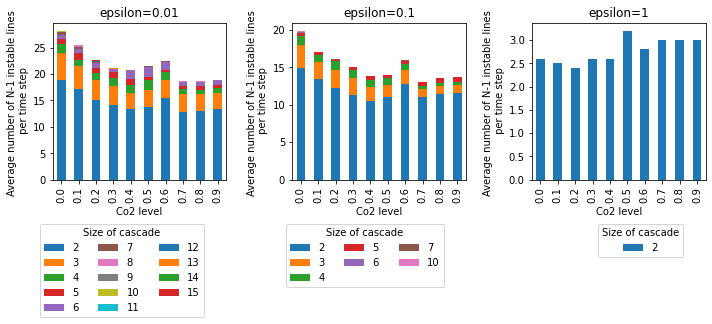

In [146]:
fig, axs = plt.subplots(1, len(epsilon_list), figsize=(10,5))
for ax,epsilon in zip(axs,epsilon_list):
    
    data=cascade_results[cascade_results.epsilon==epsilon].groupby(by=['co2l', 'n_cascade_links', 'snapshot']).size().unstack('snapshot').fillna(0).mean(1).unstack()
    data.reset_index(inplace=True, drop=True)
    data.plot.bar(stacked=True, ax=ax)
    ax.set_xticklabels(co2l_list)
    ax.legend(ncol=3, bbox_to_anchor=(0.9,-0.25), title='Size of cascade')
    ax.set_ylabel('Average number of N-1 instable lines \n per time step')
    ax.set_title('epsilon={}'.format(epsilon))
    ax.set_xlabel('Co2 level')
plt.tight_layout()

/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:400: MatplotlibDeprecationWarning: 
The is_first_col function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use ax.get_subplotspec().is_first_col() instead.
  if ax.is_first_col():


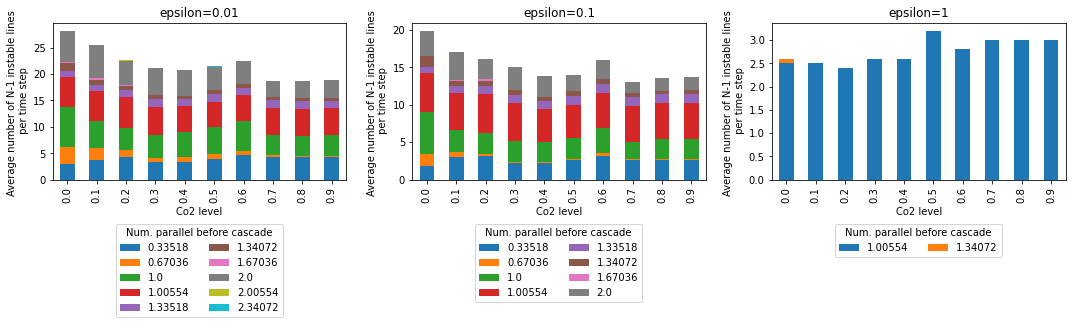

In [209]:
fig, axs = plt.subplots(1, len(epsilon_list), figsize=(15,5))
for ax,epsilon in zip(axs,epsilon_list):
    
    cascade_results.loc[:, 'num_parallel_before'] = np.around(cascade_results.loc[:, 'num_parallel_before'].values, 5)
    data=cascade_results[cascade_results.epsilon==epsilon].groupby(by=['co2l', 'num_parallel_before', 'snapshot']).size().unstack('snapshot').fillna(0).mean(1).unstack()
    data.reset_index(inplace=True, drop=True)
    data.plot.bar(stacked=True, ax=ax)
    ax.set_xticklabels(co2l_list)
    ax.legend(ncol=2, bbox_to_anchor=(0.8,-0.25), title='Num. parallel before cascade')
    ax.set_ylabel('Average number of N-1 instable lines \n per time step')
    ax.set_title('epsilon={}'.format(epsilon))
    ax.set_xlabel('Co2 level')
plt.tight_layout()



In [192]:
cascade_results.groupby(by=['co2l', 'epsilon', 'snapshot']).size().to_frame('number').reset_index()

,co2l,epsilon,snapshot,number
0,0.0,0.01,2013-01-16 21:00:00,47
1,0.0,0.01,2013-01-27 12:00:00,21
2,0.0,0.01,2013-03-25 21:00:00,31
3,0.0,0.01,2013-04-25 21:00:00,15
4,0.0,0.01,2013-05-18 00:00:00,20
...,...,...,...,...
295,0.9,1.00,2013-07-02 18:00:00,4
296,0.9,1.00,2013-11-03 21:00:00,2
297,0.9,1.00,2013-11-05 00:00:00,2
298,0.9,1.00,2013-11-14 21:00:00,3


Text(0, 0.5, 'Number of N-1 instable lines \n per time step')

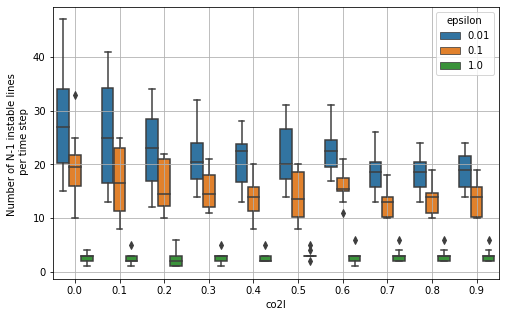

In [199]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=cascade_results.groupby(by=['co2l', 'epsilon', 'snapshot']).size().to_frame('number').reset_index(), x='co2l', y='number', hue='epsilon', ax=ax)
ax.grid()
ax.set_ylabel('Number of N-1 instable lines \n per time step')

In [212]:
co2l = 0.1
epsilon = 0.1

cascade_results[(cascade_results.co2l==co2l)&(cascade_results.epsilon==epsilon)&(cascade_results.n_cascade_links>3)]

,snapshot,co2l,epsilon,init_failure_idx,init_failure,num_parallel_before,num_parallel_after,n_cascade_links
553,2013-01-16 21:00:00,0.1,0.1,150,"(BE0 7, NL0 15)",2.00000,1.00000,5
561,2013-01-16 21:00:00,0.1,0.1,692,"(FR0 73, FR0 43)",1.00554,0.00554,4
610,2013-11-14 21:00:00,0.1,0.1,427,"(DE0 124, DE0 62)",2.00000,1.00000,4
611,2013-11-14 21:00:00,0.1,0.1,438,"(DE0 62, DK0 2)",2.00000,1.00000,4
612,2013-11-14 21:00:00,0.1,0.1,519,"(ES0 12, FR0 94)",1.33518,0.33518,5
671,2013-01-27 12:00:00,0.1,0.1,391,"(DE0 36, DE0 118)",1.34072,0.34072,4
687,2013-01-27 12:00:00,0.1,0.1,918,"(NL0 12, NL0 16)",2.00000,1.00000,5
744,2013-03-25 21:00:00,0.1,0.1,150,"(BE0 7, NL0 15)",2.00000,1.00000,4
819,2013-12-27 06:00:00,0.1,0.1,391,"(DE0 36, DE0 118)",1.34072,0.34072,4
827,2013-12-27 06:00:00,0.1,0.1,773,"(GR0 11, GR0 9)",2.00000,1.00000,4


In [222]:
# Plot map of system split and failing lines for one initial failure

event_idx = 687
snapshot = cascade_results.iloc[event_idx].snapshot

failing_links_idx = cascade_list[event_idx]
print('failing_links', failing_links_idx, '\n')
failing_links = utils.transform_cascade_results(G, failing_links_idx)
print('failing_links', failing_links, '\n')
initial_failure_idx = failing_links_idx[0]
init_failure = failing_links[0]

# Load PyPSA network
network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+f'sclopf-elec_s_800_ec_lv1.0_Co2L{co2l}-3H.nc')
line_info = network.lines[(network.lines.bus0==init_failure[0])&(network.lines.bus1==init_failure[1])]
if line_info.empty:
    line_info = network.lines[(network.lines.bus1==init_failure[0])&(network.lines.bus0==init_failure[1])]
#TODO: add function for this. Adding time stamps is necessary because they are missing in the pypsa networks
network.snapshots = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))

network.snapshot_weightings.index = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))

for component in network.all_components:
    pnl = network.pnl(component)
    attrs = network.components[component]["attrs"]

    for k,default in attrs.default[attrs.varying].iteritems():
        pnl[k].index = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))
######
    
    
line_info


failing_links [918, 918, 450, 913, 934] 

failing_links [('NL0 12', 'NL0 16'), ('NL0 12', 'NL0 16'), ('NL0 0', 'NL0 8'), ('NL0 8', 'NL0 22'), ('NL0 22', 'NL0 2')] 



/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jokruse/anaconda3/envs/system_split/lib/python3.7/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network sclopf-elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, lines, links, loads, storage_units


,bus0,bus1,num_parallel,length,type,s_max_pu,s_nom,capital_cost,x,r,...,s_nom_min,s_nom_max,terrain_factor,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu
name,,,,,,,,,,,,,,,,,,,,,
1037,NL0 12,NL0 16,2.0,50.579991,Al/St 240/40 4-bundle 380.0,0.7,3396.205223,1927.384193,6.221339,0.7587,...,0.0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
1037_outage,NL0 12,NL0 16,1.0,50.579991,Al/St 240/40 4-bundle 380.0,0.7,1698.102612,1927.384193,12.442678,1.5174,...,0.0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0


Components after 1st failure:  1
Overloaded line indices:  [918]
Num. parallel on initial failing line before:  2.0 ; and after:  1.0
Flow on initial failing line after its failure:  1985.0066165340706
Line limit of initial failing line after its failure:  1698.1026117405274


(<matplotlib.collections.PatchCollection at 0x7fe434dee310>,
 <matplotlib.collections.LineCollection at 0x7fe434628490>)

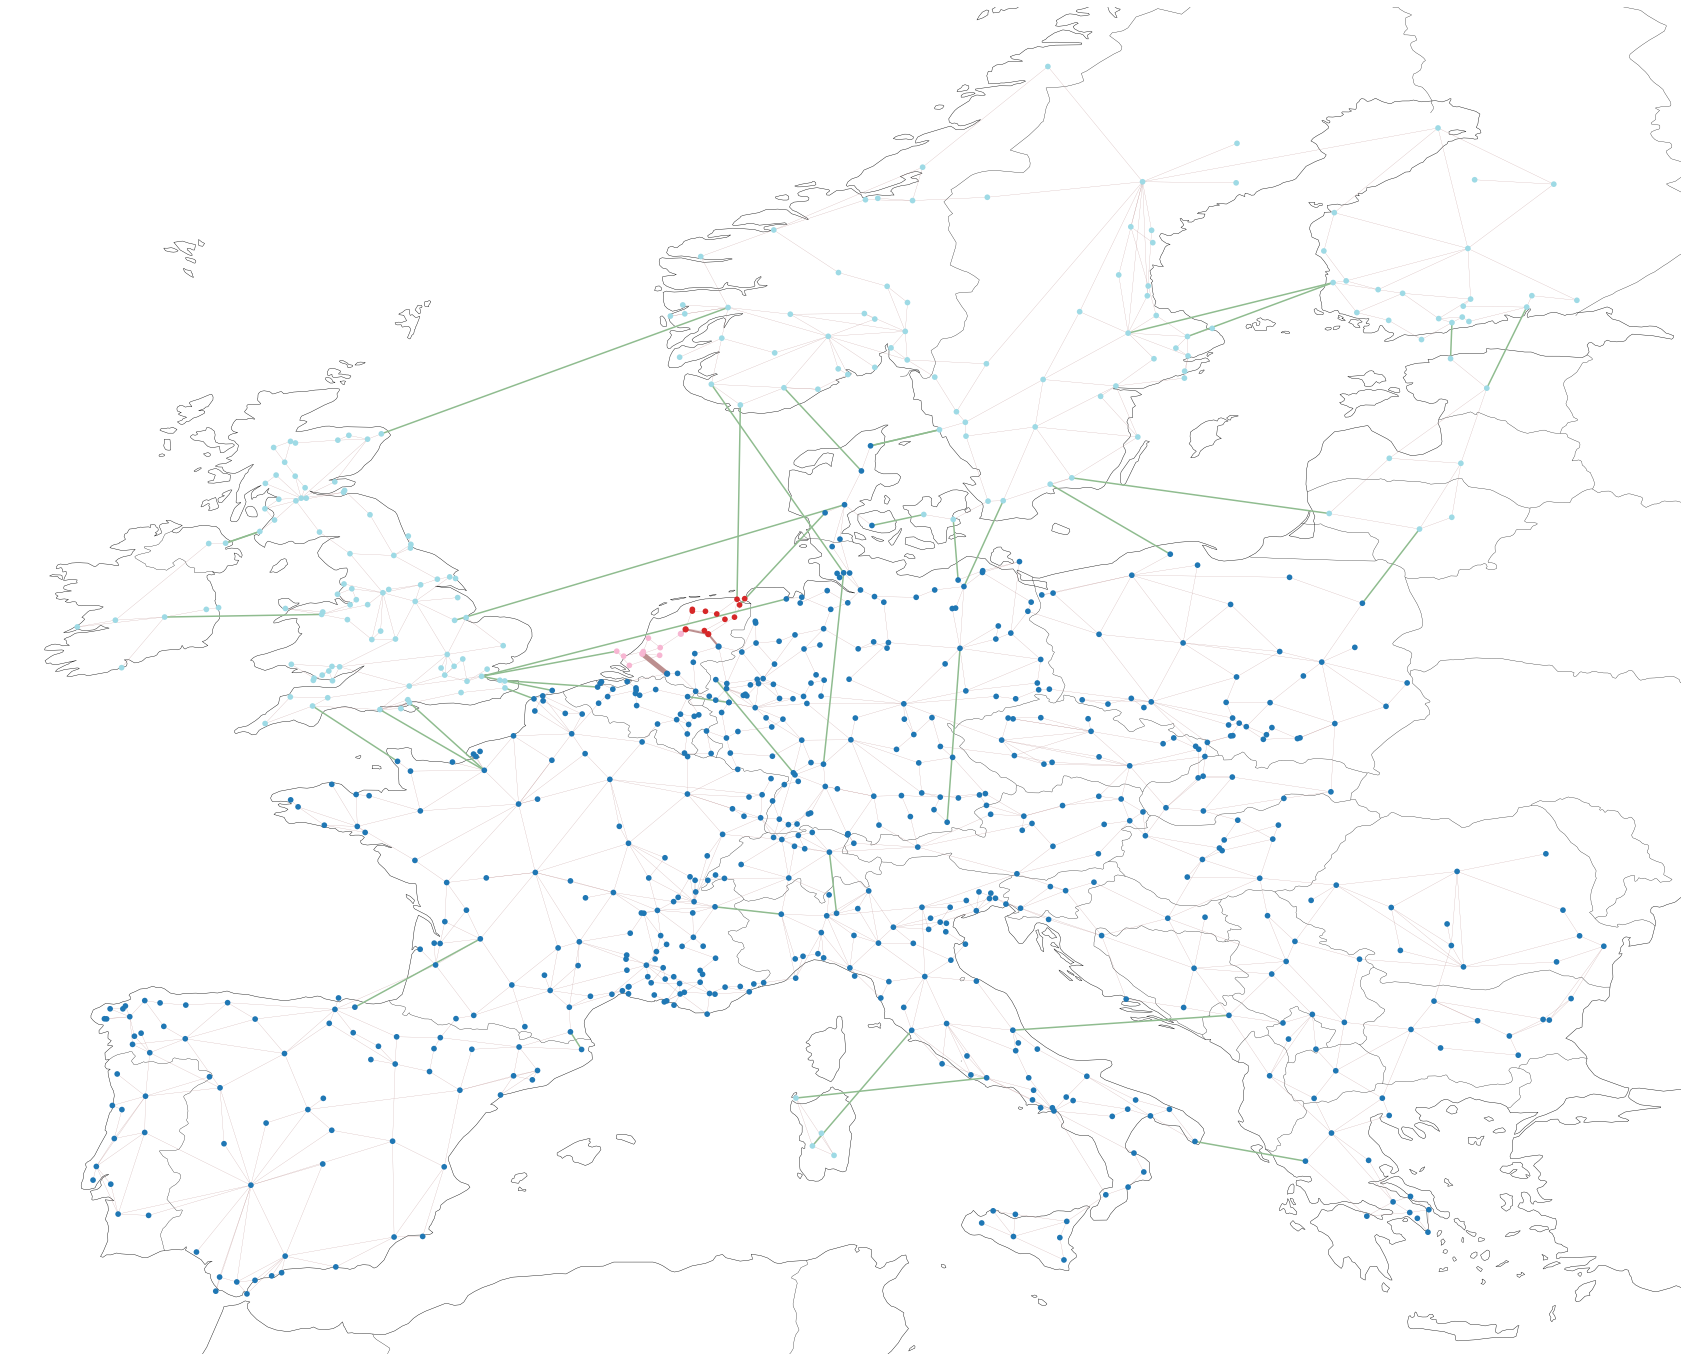

In [230]:


# The following line is needed to remove the outage lines used for SCLOPF. When not removed, multiple edges 
# are added to the network graph
outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index
network.mremove('Line', outage_lines)
network.determine_network_topology()

initial_loading = {e: np.sum([network.lines_t.p0.loc[snapshot].loc[index] for index in index_list]) for
                    e, index_list in nx.get_edge_attributes(G, 'line_index').items()}
P0 = utils.get_effective_injections(G, initial_loading)

plt.figure(figsize=(30,30))
lws = np.ones(network.lines.shape[0])*0.2
bs = np.ones(network.buses.shape[0])*0.005
bc = np.ones(network.buses.shape[0])

for e in failing_links[1:]:
    lws[((network.lines.bus0==e[0])&(network.lines.bus1==e[1]))|((network.lines.bus0==e[1])&(network.lines.bus1==e[0]))]=2
    bs[network.buses.index==e[0]] =0.006
    bs[network.buses.index==e[1]] =0.006
    
for e in failing_links[:1]:
    lws[((network.lines.bus0==e[0])&(network.lines.bus1==e[1]))|((network.lines.bus0==e[1])&(network.lines.bus1==e[0]))]=5
    bs[network.buses.index==e[0]] =0.006
    bs[network.buses.index==e[1]] =0.006
    
# Simulate initial failure
G_2 = G.copy()     
I_m_2 =  I_m.copy()
B_d_2 = B_d.copy()
num_parallel_list_2 = num_parallel_list.copy()
line_limit_list_2 = line_limit_list.copy()

cascade_sim.remove_line_from_Bd(B_d_2, num_parallel_list_2,
                          line_limit_list_2, initial_failure_idx)
    


# Check if network is still connected
LL_r = I_m_2.dot(B_d_2).dot(I_m_2.T)
AA = - LL_r + sparse.diags(LL_r.diagonal())
    
nr_components = connected_components(AA)[0]


# Solve the power flow Equation
theta = sparse.linalg.spsolve(LL_r, P0)
flows = B_d_2.dot((I_m_2.T).dot(theta))

# Check line limits
idxs_overloaded =  np.where(abs(flows) > line_limit_list_2*(1+epsilon))[0]

    
# Print info
print('Components after 1st failure: ', nr_components)
print('Overloaded line indices: ', idxs_overloaded)
print('Num. parallel on initial failing line before: ', num_parallel_list[initial_failure_idx],
      '; and after: ', num_parallel_list_2[initial_failure_idx])
print('Flow on initial failing line after its failure: ', flows[initial_failure_idx])
print('Line limit of initial failing line after its failure: ', line_limit_list_2[initial_failure_idx] )    

# Remove failing links during cascade from graph
removed_init_links = []
n_par_new = cascade_sim.calc_num_parallel_after_failure(G_2.get_edge_data(init_failure[0], init_failure[1])['num_parallel'])
G_2.get_edge_data(init_failure[0], init_failure[1])['num_parallel'] = n_par_new
if n_par_new==0:
    removed_init_links += [init_failure]
G_2.remove_edges_from(failing_links[1:]+removed_init_links)    
    
# Calculate subgraphs in case of a split
subgraphs =  list((G_2.subgraph(c).copy() for c in nx.connected_components(G_2)))
for i in range(network.buses.shape[0]):
    bus = network.buses.index[i]
    for j, subgraph in enumerate(subgraphs):
        if bus in subgraph:
            bc[i]=(np.arange(len(subgraphs))/len(subgraphs))[j]

network.plot(line_widths=lws, bus_sizes=bs, jitter=0.2, bus_colors=bc, bus_cmap='tab20')

### profile cascade algorithm

In [ ]:

# Load co2 level
co2l = 0.9 # float(sys.argv[1])

# Load PyPSA network
network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+f'sclopf-elec_s_800_ec_lv1.0_Co2L{co2l}-3H.nc')


# The following line is needed to remove the outage lines used for SCLOPF. When not removed, multiple edges 
# are added to the network graph
outage_lines = network.lines[network.lines.index.str[-6:]=='outage'].index
network.mremove('Line', outage_lines)
network.determine_network_topology()



######
#TODO: remove this line if the networks contain timestamp snapshots
network.snapshots = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))

network.snapshot_weightings.index = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))

for component in network.all_components:
    pnl = network.pnl(component)
    attrs = network.components[component]["attrs"]

    for k,default in attrs.default[attrs.varying].iteritems():
        pnl[k].index = pd.date_range(start='2013', freq='3H', periods=len(network.snapshots))
######


# Select a particular subnetwork for calculations (if the pypsa network has different ones).
# Otherwise you can choose None or -1.
# For our data set, "0" indicates the Continental European AC grid. 
snet_index = 0

# Build graph for subnetwork
G = utils.build_networkx_graph(network, snet_index= snet_index)


# Get line index 
# Line index is a unique number to identify the given edge.
# It is directly extracted from pypsa
indices = nx.get_edge_attributes(G, 'line_index')

# Extract time steps
snapshot = network.snapshots[1000]

# Build incidence matrix and susceptance matrix
I_m = utils.construct_incidencematrix_from_orientation(G,return_np_array = False) 
B_d = spdiags(np.array([attribs['weight'] for u,v, attribs in G.edges(data=True)]),
              0,G.number_of_edges(),G.number_of_edges()).asformat('csc')

# Get array of num_parallels and of line limits
num_parallel_list = np.array([attribs['num_parallel'] for u,v, attribs in G.edges(data=True)])
line_limit_list = np.array([attribs['s_nom'] for u,v, attribs in G.edges(data=True)])

# Calculate possible double line failure (using non-bridges)
bridges = list(nx.bridges(nx.Graph(G)))
link_indices = dict(zip(G.edges(), range(G.number_of_edges())))
bridges_indices = [link_indices[link_name] for link_name in bridges]
possible_failures = cascade_sim.calc_possible_double_line_failures(num_parallel_list,
                                                                   bridges_indices)

initial_loading = {e: np.sum([network.lines_t.p0.loc[snapshot].loc[index] for index in index_list]) for
                    e, index_list in indices.items()}
P_0 = utils.get_effective_injections(G, initial_loading)

l_copy = initial_loading.copy()
for key in l_copy.keys():
    initial_loading[key[::-1]] = initial_loading[key]


In [5]:
def profiling_function(I_m, B_d, P_0, line_limit_list,num_parallel_list,possible_failures):
    
    for i, initial_failure in enumerate(possible_failures):
        failing_links, system_split = cascade_sim.simulate_cascade(I_m, B_d, P_0, line_limit_list,
                                                                num_parallel_list, initial_failure)
            
%lprun -f cascade_sim.simulate_cascade profiling_function(I_m, B_d, P_0, line_limit_list,num_parallel_list,possible_failures[:5000])

Timer unit: 1e-06 s

Total time: 19.3142 s
File: /media/jkruse/Projects/system_splits/power-system-split/power_system_split/cascade_sim.py
Function: simulate_cascade at line 98

Line #      Hits         Time  Per Hit   % Time  Line Contents
    98                                           def simulate_cascade(II_in, B_d_in,
    99                                                                P0, line_limits_in, num_parallel_in, failure_links):
   100                                               """Simulate a cascade with the given inital failure links:
   101                                           
   102                                               Args:
   103                                                   II_in (sparse matrix): Incidence matrix
   104                                                   B_d_in (_type_): Diagonal matrix with susecptance on diagonal.
   105                                                   P0 (1d numpy array): power injections/extractions 
   10

In [117]:
t_sim = 12 # in seconds
n_init_failures = 5000 # number of initial failures simulated
t_total = (network.snapshots.shape[0]*t_sim*len(possible_failures)/n_init_failures)/3600/24

print('Estimated time for simulating one Co2 level:',
      round(t_total),
      ' d')

Estimated time for simulating one Co2 level: 37  d


### Plot failing links for one example initial failure


In [20]:
# Simulate cascade for every tuple of trigger links
# Print if a split happened

split_results = {'date1':[]}
i=0

selected_possible_failures = np.array(possible_failures)[np.random.randint(0,len(possible_failures),1000)]

for init_failure in tqdm(selected_possible_failures):

    initial_failure = list(init_failure)
    failing_links, system_split = cascade_sim.simulate_cascade(I_m, B_d, P_0, line_limit_list,
                                                                num_parallel_list, initial_failure)
    if system_split:
        split_results['date1'].append(failing_links)
    i+=1

100%|██████████| 1000/1000 [00:02<00:00, 380.74it/s]


In [16]:
# Find keys with large system splits
for item in split_results['date1']:
    if len(item)>4:
        print(item)

failing_links [('DE0 94', 'DE0 18'), ('BE0 7', 'NL0 15'), ('BE0 7', 'NL0 15'), ('BE0 4', 'NL0 26'), ('LU0 0', 'DE0 118'), ('DE0 36', 'DE0 35'), ('DE0 122', 'DE0 41'), ('DE0 37', 'DE0 40'), ('DE0 122', 'DE0 39'), ('DE0 100', 'DE0 112'), ('DE0 100', 'DE0 114'), ('DE0 114', 'DE0 116'), ('DE0 50', 'DE0 51'), ('DE0 51', 'DE0 92'), ('DE0 94', 'DE0 18'), ('AT0 5', 'IT0 16'), ('AT0 8', 'CZ0 1'), ('HU0 2', 'SK0 1'), ('CZ0 0', 'DE0 107'), ('DE0 107', 'DE0 49'), ('DE0 107', 'DE0 51'), ('DE0 107', 'DE0 78'), ('CZ0 15', 'SK0 0'), ('DE0 17', 'DE0 15'), ('DE0 17', 'DE0 18'), ('DE0 119', 'DE0 16'), ('DE0 114', 'DE0 122'), ('DE0 114', 'DE0 49'), ('DE0 105', 'DE0 46'), ('DE0 46', 'DE0 66'), ('DE0 51', 'DE0 15'), ('DE0 78', 'DE0 45'), ('DE0 28', 'NL0 0'), ('DE0 16', 'DE0 18'), ('DE0 27', 'DE0 29'), ('SI0 3', 'IT0 61'), ('HU0 5', 'SK0 5'), ('PL0 1', 'PL0 31')] 

('DE0 94', 'DE0 18') 1.0
('BE0 7', 'NL0 15') 1.0
[] [('DE0 94', 'DE0 18'), ('BE0 7', 'NL0 15')]


(<matplotlib.collections.PatchCollection at 0x7fb362d37e10>,
 <matplotlib.collections.LineCollection at 0x7fb35e371f90>)

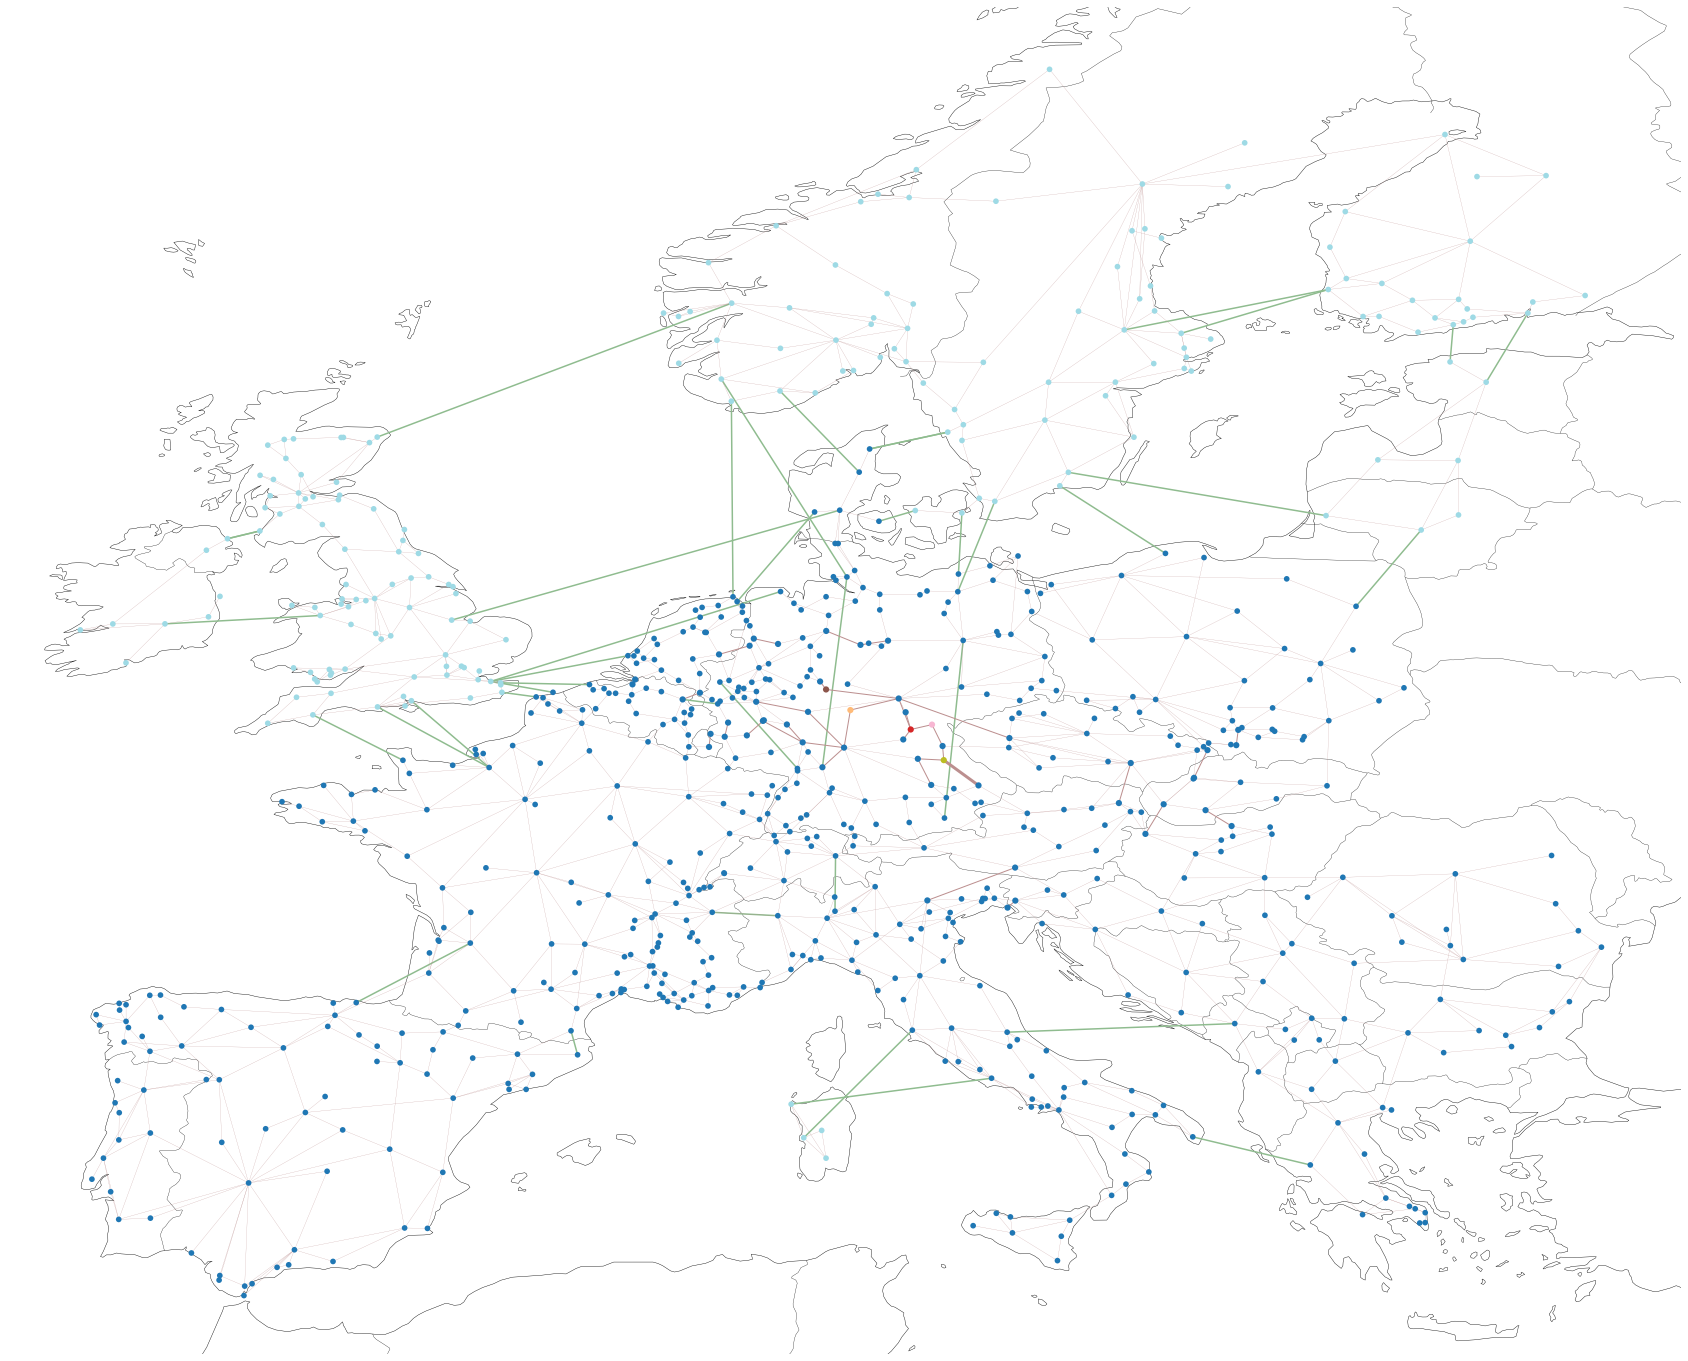

In [20]:
# Plot map of system split and failing lines for one key
#idx_key = 529
#idx = 10
#failing_links = split_results[idx_key] 
#failing_links = split_results[list(split_results.keys())[idx]]
failing_links = [33, 150, 150, 121, 149, 392, 334, 452, 333, 311, 312, 322, 383, 385, 33, 44, 63, 79, 248, 263, 265, 267, 273, 293, 294, 302, 323, 326, 356, 368, 384, 386, 415, 421, 446, 779, 800, 968]

link_names = dict(zip(range(G.number_of_edges()), G.edges()))
failing_links = [link_names[link] for link in failing_links]
print('failing_links', failing_links, '\n')

plt.figure(figsize=(30,30))
lws = np.ones(network.lines.shape[0])*0.2
bs = np.ones(network.buses.shape[0])*0.005
bc = np.ones(network.buses.shape[0])

for e in failing_links[2:]:
    lws[((network.lines.bus0==e[0])&(network.lines.bus1==e[1]))|((network.lines.bus0==e[1])&(network.lines.bus1==e[0]))]=1
    bs[network.buses.index==e[0]] =0.006
    bs[network.buses.index==e[1]] =0.006
    
for e in failing_links[:2]:
    lws[((network.lines.bus0==e[0])&(network.lines.bus1==e[1]))|((network.lines.bus0==e[1])&(network.lines.bus1==e[0]))]=3
    bs[network.buses.index==e[0]] =0.006
    bs[network.buses.index==e[1]] =0.006
    
G_2 = G.copy()     
init_failures = failing_links[:2]
removed_init_links = []
for link in init_failures:
    n_par_new = cascade_sim.calc_num_parallel_after_failure(G_2.get_edge_data(link[0], link[1])['num_parallel'])
    G_2.get_edge_data(link[0], link[1])['num_parallel'] = n_par_new
    print(link, n_par_new)
    if n_par_new==0:
        removed_init_links += [link]
G_2.remove_edges_from(failing_links[2:]+removed_init_links)
    
    
subgraphs =  list((G_2.subgraph(c).copy() for c in nx.connected_components(G_2)))

for i in range(network.buses.shape[0]):
    bus = network.buses.index[i]
    for j, subgraph in enumerate(subgraphs):
        if bus in subgraph:
            bc[i]=(np.arange(len(subgraphs))/len(subgraphs))[j]

network.plot(line_widths=lws, bus_sizes=bs, jitter=0.1, bus_colors=bc, bus_cmap='tab20')